# Analyse exploratoire des données

In [1]:
#Importation des bibliotheques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
#Chargement du dataset
df=pd.read_csv('student_habits_performance.csv')

In [64]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [65]:
df.shape

(1000, 16)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [67]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [68]:
#Suppression des valeurs manquantes
df['parental_education_level']=df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [69]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [70]:
#Statistiques de base des variables numériques
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


In [71]:
#Statistiques de base des variables catégorielles
df.describe(include='object').transpose()

,count,unique,top,freq
student_id,1000,1000,S1999,1
gender,1000,3,Female,481
part_time_job,1000,2,No,785
diet_quality,1000,3,Fair,437
parental_education_level,1000,3,High School,483
internet_quality,1000,3,Good,447
extracurricular_participation,1000,2,No,682


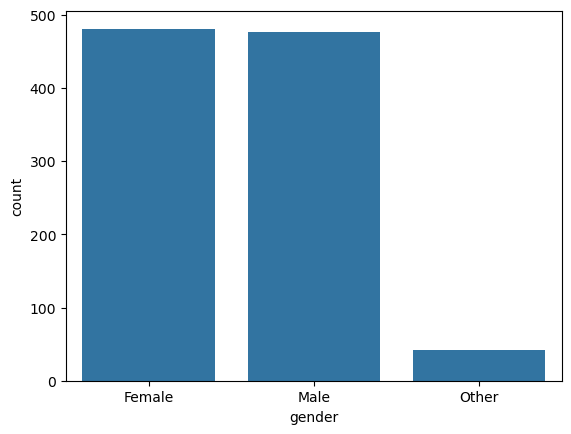

In [72]:
sns.countplot(x='gender',data=df);

### Une répartition presque uniforme des sexes des étudiants avec un peu plus de femmes que d'hommes

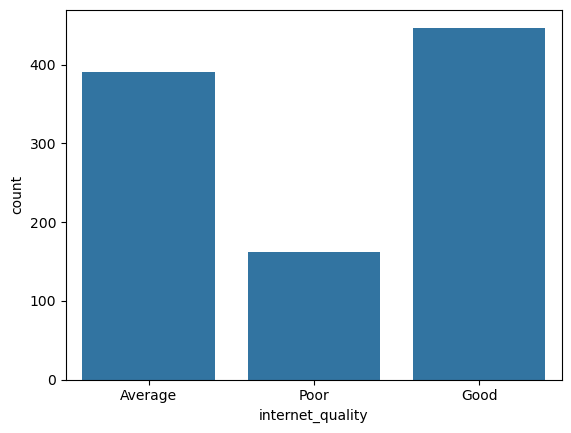

In [73]:
sns.countplot(x='internet_quality',data=df);

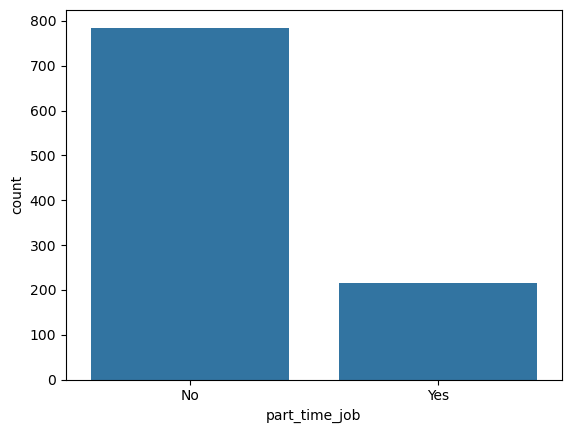

In [74]:
sns.countplot(x='part_time_job',data=df);

### La majorité des élèves ne travaille pas

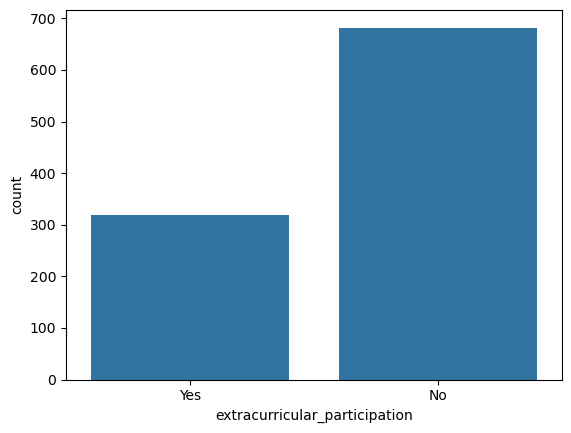

In [75]:
sns.countplot(x="extracurricular_participation",data=df);

### La majorité des élèves ne participe pas aux actiavités extra scolaires

In [76]:
df=df.drop('student_id',axis=1)

In [77]:
#Encodage des variables catégorielles
numeric=df.select_dtypes(exclude="object")
objet=df.select_dtypes(include='object')

In [78]:
objet=pd.get_dummies(objet,drop_first=True).astype(int)

In [79]:
df_final=pd.concat([objet,numeric],axis=1)

In [80]:
df_final

,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
0,False,False,False,False,False,False,True,False,False,True,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2
1,False,False,False,True,False,True,False,False,False,False,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0
2,True,False,False,False,True,True,False,False,True,False,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3
3,False,False,False,False,True,False,True,True,False,True,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8
4,False,False,False,False,False,False,True,True,False,False,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,True,False,True,False,True,21,2.6,0.5,1.6,77.0,7.5,2,6,76.1
996,False,False,True,False,True,True,False,False,False,True,17,2.9,1.0,2.4,86.0,6.8,1,6,65.9
997,True,False,False,True,False,False,False,True,False,True,20,3.0,2.6,1.3,61.9,6.5,5,9,64.4
998,True,False,True,False,False,False,False,False,False,False,24,5.4,4.1,1.1,100.0,7.6,0,1,69.7


In [81]:
# Séparation des features et de la target

x=df_final.drop('exam_score',axis=1)
y=df_final['exam_score'].values.reshape(-1,1)

In [82]:
x.shape

(1000, 18)

In [83]:
y.shape

(1000, 1)

In [84]:
from sklearn.model_selection import train_test_split


In [85]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [86]:
from sklearn.preprocessing import StandardScaler
scale_linear=StandardScaler()

In [87]:
X_train_scaled=scale_linear.fit_transform(X_train)
X_test_scaled=scale_linear.transform(X_test)

# Regression Linéaire Multiple

In [88]:
X_train_lin=np.hstack((X_train_scaled,np.ones((X_train_scaled.shape[0],1))))
X_test_lin= np.hstack((X_test_scaled, np.ones((X_test_scaled.shape[0], 1))))

In [89]:
X_train_lin.shape

(700, 19)

In [90]:
X_test_lin.shape

(300, 19)

In [91]:
y.shape

(1000, 1)

In [92]:
#Initialisation de theta
theta=np.random.rand(X_train_lin.shape[1],1)

In [93]:
theta.shape

(19, 1)

In [94]:
#Implémentation de la fonction du modèle
def model(X,theta):
    return X.dot(theta)

In [95]:
# Implémentation de la fonction de cout
def cost_function(X,y,theta):
    m=len(y)
    return 1/(2*m) * np.sum((model(X,theta)-y)**2)

In [96]:
cost_function(X_train_lin,y_train,theta)

np.float64(2515.788538904584)

In [97]:
# Implémentation du gradient

def gradient(X,y,theta):
    m=len(y)
    return 1/m * X.T.dot(model(X,theta)-y)
    

In [98]:
#Implémentation du gradient descent
def gradient_descent(X,y,theta,learning_rate,n_iterations):
    cost_history=np.zeros(n_iterations)
    for i in range (0,n_iterations):
        theta=theta-learning_rate*gradient(X,y,theta)
        cost_history[i]=cost_function(X,y,theta)
    return theta,cost_history


In [99]:
theta_final,cost_history=gradient_descent(X_train_lin,y_train,theta,learning_rate=0.01,n_iterations=1000)

In [100]:
theta_final

array([[ 1.51446653e-01],
       [ 1.54282553e-01],
       [ 7.80527799e-03],
       [-4.77766965e-01],
       [-2.28761161e-01],
       [-2.41583450e-01],
       [-4.26350334e-02],
       [-7.88389024e-02],
       [-3.70210775e-02],
       [-3.44362531e-02],
       [ 1.46357611e-01],
       [ 1.40328012e+01],
       [-3.20256076e+00],
       [-2.61054547e+00],
       [ 1.36545178e+00],
       [ 2.47132947e+00],
       [ 2.58508990e+00],
       [ 5.53343985e+00],
       [ 6.98765900e+01]])

In [101]:
predictions_train=model(X_train_lin,theta_final)

In [102]:
predictions_test=model(X_test_lin,theta_final)

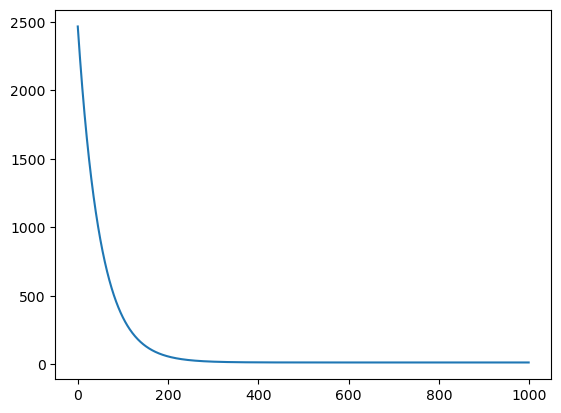

In [103]:
plt.plot(range(1000),cost_history)
plt.show()

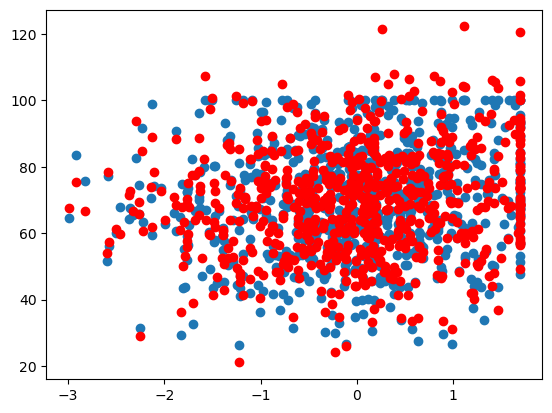

In [104]:
#visualisation par rapport à la 2eme variable
plt.scatter(X_train_lin[:,14],y_train)
plt.scatter(X_train_lin[:,14],predictions_train,c="r")
plt.show()


In [105]:
def coefficient_determination(y,pred):
    u=((y-pred)**2).sum()
    v=((y-y.mean())**2).sum()
    return 1- u/v

In [106]:
coefficient_determination(y_test,predictions_test)

np.float64(0.8971301200669707)

### Le Mean Square Error mesure les erreurs entre les valeurs prédites et les valeurs réelles de notre dataset

In [107]:
def mean_square_error(y,pred):
    m=len(y)
    u=((y-pred)**2).sum()
    return 1/m * u

In [108]:
mean_square_error(y_test,predictions_test)

np.float64(28.573284565506984)

# Regression Linéaire Polynomiale

In [120]:
# Combinaison A : termes quadratiques uniquement sur les variables numeriques continues
numeric_cols = ['age','study_hours_per_day','social_media_hours',
                'netflix_hours','attendance_percentage',
                'sleep_hours','exercise_frequency','mental_health_rating']

x_poly_train = X_train[numeric_cols] ** 2
x_poly_test = X_test[numeric_cols] ** 2

In [121]:
x_poly_train.shape, x_poly_test.shape

In [122]:
scale_poly=StandardScaler()
x_poly_train_scaled=scale_poly.fit_transform(x_poly_train)
x_poly_test_scaled=scale_poly.transform(x_poly_test)

In [141]:
# On concatene les features lineaires scalees + les termes quadratiques + le biais
X_poly_train=np.hstack((X_train_scaled, x_poly_train_scaled, np.ones((X_train_scaled.shape[0],1))))
X_poly_test=np.hstack((X_test_scaled, x_poly_test_scaled, np.ones((X_test_scaled.shape[0],1))))

In [142]:
X_poly_train.shape

(700, 37)

In [143]:
X_poly_test.shape

(300, 37)

In [145]:
#Initialisation de theta
theta_poly=np.random.rand(X_poly_train.shape[1],1)

In [156]:
theta_final_poly,cost_history_poly=gradient_descent(X_poly_train,y_train,theta_poly,learning_rate=0.01,n_iterations=5000)

In [157]:
# Affichage des coefficients du modele
theta_final_poly

array([[-2.06332134e-01],
       [ 1.06033120e-01],
       [-1.97862660e-01],
       [-4.80230403e-01],
       [ 3.10859469e-02],
       [-3.54152329e-01],
       [-4.02341497e-01],
       [ 2.44760823e-01],
       [-8.03544868e-02],
       [-1.86294004e-01],
       [ 1.92726200e-01],
       [-1.44251310e+00],
       [ 1.32339563e+00],
       [ 1.55200408e-01],
       [ 6.98664844e-01],
       [ 1.70456539e+00],
       [ 4.31470860e-01],
       [ 1.30964910e+00],
       [ 3.62664081e-01],
       [ 3.39885770e-02],
       [ 1.92479823e-01],
       [-2.23100180e-02],
       [-2.63499889e-01],
       [ 1.30688685e-01],
       [ 3.77304743e-01],
       [-3.74165777e-01],
       [-1.23749216e-02],
       [ 1.88742333e-01],
       [-9.01051093e-02],
       [ 1.53903575e+01],
       [-4.45062647e+00],
       [-2.74742822e+00],
       [ 7.10596116e-01],
       [ 7.43365118e-01],
       [ 2.21243931e+00],
       [ 4.24912826e+00],
       [ 6.98795714e+01]])

In [158]:
predictions_train_poly=model(X_poly_train,theta_final_poly)

In [159]:
predictions_test_poly=model(X_poly_test,theta_final_poly)

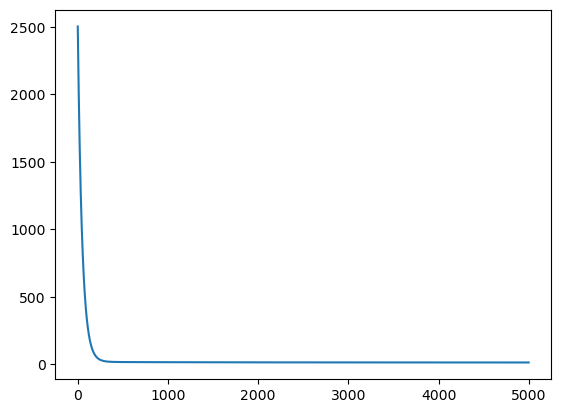

In [160]:
#Evolution de la fonction de coût
plt.plot(range(5000),cost_history_poly)
plt.show()

In [161]:
coefficient_determination(y_test,predictions_test_poly)

np.float64(0.898942238404306)

In [162]:
mean_square_error(y_test,predictions_test_poly)

np.float64(28.06994799164529)

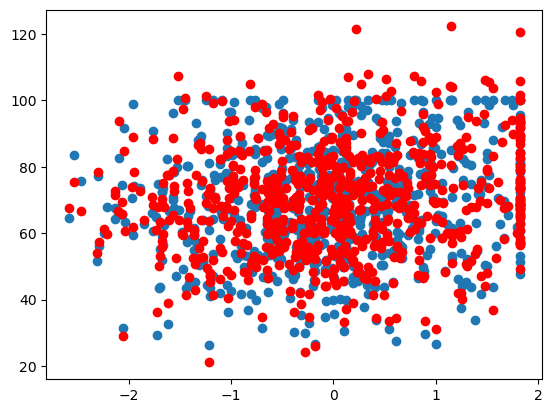

In [153]:
# Visualisation par rapport a attendance_percentage (choix explicite)
att_idx = X_train.columns.get_loc('attendance_percentage')
plt.scatter(X_train_scaled[:,att_idx],y_train)
plt.scatter(X_train_scaled[:,att_idx],predictions_train_poly,c="r")
plt.show()


## Combinaisons ajoutees d'apres le rapport

- **A (deja appliquee au bloc polynomial)** : termes quadratiques uniquement sur les variables numeriques continues.
- **B** : ajout d'un terme d'interaction `study_hours_per_day * attendance_percentage`.
- **C** : generation automatique des termes de degre 2 avec `PolynomialFeatures`.

Les resultats compares sont produits automatiquement dans la cellule `results` ci-dessous.

In [ ]:
# Combinaison B : interaction study_hours_per_day * attendance_percentage
X_train_B = X_train.copy()
X_test_B = X_test.copy()

X_train_B['study_x_attend'] = X_train_B['study_hours_per_day'] * X_train_B['attendance_percentage']
X_test_B['study_x_attend'] = X_test_B['study_hours_per_day'] * X_test_B['attendance_percentage']

scale_B = StandardScaler()
X_train_B_scaled = scale_B.fit_transform(X_train_B)
X_test_B_scaled = scale_B.transform(X_test_B)

X_train_B_final = np.hstack((X_train_B_scaled, np.ones((X_train_B_scaled.shape[0],1))))
X_test_B_final = np.hstack((X_test_B_scaled, np.ones((X_test_B_scaled.shape[0],1))))

theta_B = np.random.rand(X_train_B_final.shape[1],1)
theta_B_final, cost_history_B = gradient_descent(X_train_B_final, y_train, theta_B, learning_rate=0.01, n_iterations=5000)

predictions_test_B = model(X_test_B_final, theta_B_final)
r2_B = coefficient_determination(y_test, predictions_test_B)
mse_B = mean_square_error(y_test, predictions_test_B)

r2_B, mse_B

### C) PolynomialFeatures (degre 2) sur les variables numeriques continues
Generation systematique des termes quadratiques + interactions via scikit-learn, puis concatenation avec les variables binaires.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

binary_cols = [col for col in X_train.columns if col not in numeric_cols]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_C_num = poly.fit_transform(X_train[numeric_cols])
X_test_C_num = poly.transform(X_test[numeric_cols])

X_train_C = np.hstack((X_train[binary_cols].values, X_train_C_num))
X_test_C = np.hstack((X_test[binary_cols].values, X_test_C_num))

scale_C = StandardScaler()
X_train_C_scaled = scale_C.fit_transform(X_train_C)
X_test_C_scaled = scale_C.transform(X_test_C)

X_train_C_final = np.hstack((X_train_C_scaled, np.ones((X_train_C_scaled.shape[0],1))))
X_test_C_final = np.hstack((X_test_C_scaled, np.ones((X_test_C_scaled.shape[0],1))))

theta_C = np.random.rand(X_train_C_final.shape[1],1)
theta_C_final, cost_history_C = gradient_descent(X_train_C_final, y_train, theta_C, learning_rate=0.01, n_iterations=5000)

predictions_test_C = model(X_test_C_final, theta_C_final)
r2_C = coefficient_determination(y_test, predictions_test_C)
mse_C = mean_square_error(y_test, predictions_test_C)

X_train_C_final.shape, r2_C, mse_C

In [ ]:
# Resume comparatif automatique
r2_lin = coefficient_determination(y_test, predictions_test)
mse_lin = mean_square_error(y_test, predictions_test)

r2_poly_A = coefficient_determination(y_test, predictions_test_poly)
mse_poly_A = mean_square_error(y_test, predictions_test_poly)

results = pd.DataFrame({
    'Modele': ['Lineaire multiple', 'A: Poly continu (manuel)', 'B: Interaction study*attendance', 'C: PolynomialFeatures degre 2'],
    'R2_test': [r2_lin, r2_poly_A, r2_B, r2_C],
    'MSE_test': [mse_lin, mse_poly_A, mse_B, mse_C]
})
results

## Recommandations

- Prioriser la combinaison **A** pour limiter les doublons et conserver l'interpretabilite.
- Tester **B** si l'on veut une hypothese metier simple (synergie etude x assiduite).
- Utiliser **C** comme reference exhaustive, puis surveiller un possible surapprentissage (`R2_train >> R2_test`).
- En cas d'ecart train/test important, envisager une regularisation Ridge/Lasso.